In [1]:
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
import pandas as pd
from scipy.spatial.distance import euclidean, cosine
import glob
import os
import pickle
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr
import sys
import warnings
import json

sys.path.append('/ceph/behrens/Xiao/MazeModel')
sys.path.append('/ceph/behrens/Xiao/Grid_Worlds/GridWorldRL')
sys.path.append('/ceph/behrens/Xiao/RNN_model/RNNmodel')

import MazeModel
from MazeModel.preprocess.maze_transitions_preprocess_funcs import maze_transitions_mask

warnings.simplefilter(action='ignore')

In [2]:
def plot_heatmap(location_data, reference_vector, ref_x, ref_y, ref_vec_name='?'):
    # Extract coordinates and compute distances
    x_coords = []
    y_coords = []
    distances = []

    for location, data in location_data.items():
        x_coords.append(data['x_coord'])
        y_coords.append(data['y_coord'])
        dist = cosine(data['mean_vector'], reference_vector)
        distances.append(dist)

    distances_normalized = (distances - np.min(distances)) / (np.max(distances) - np.min(distances))

    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(x_coords, y_coords, c=distances_normalized, alpha=(1 - distances_normalized), s=200, cmap='autumn', edgecolor='black')

    # Highlight the reference location with a circle
    plt.scatter(ref_x, ref_y, s=300, facecolor='none', edgecolor='red', linewidth=2.5, label='Reference')

    plt.colorbar(scatter, label='Normalized Euclidean Distance')
    plt.title(f"Location Heatmap - Reference: {ref_vec_name}")
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.show()

A1 0.17311783240201953 0.17580885541801983


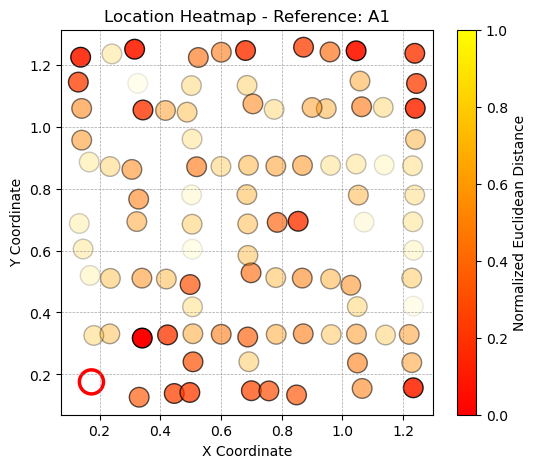

A2 0.15956758529445794 0.3391696441185121


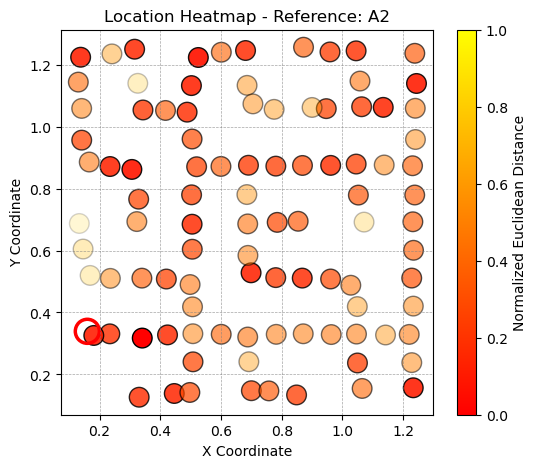

In [ ]:
import string
mouse_num = 'm3'
maze = 1
path = f"/ceph/behrens/peter_doohan/goalNav_mFC_refactor/code/GridMaze/analysis/xiao_explore/RSA/{mouse_num}/maze{maze}"
for session in range(10):
    try:
        with open(f'{path}/session{session}_part1.pkl', 'rb') as file:
            location_data = pickle.load(file)

        with open(f'{path}/session{session}_part2.pkl', 'rb') as file:
            location_data_2 = pickle.load(file)

        locs = [i+str(j)for i in string.ascii_uppercase[:7] for j in range(1, 8)]
        
        for loc in locs:
            try:
                reference_location = loc
                reference_vector = location_data_2[reference_location]['mean_vector']
                ref_x = location_data_2[reference_location]['x_coord']
                ref_y = location_data_2[reference_location]['y_coord']
                print(loc, ref_x, ref_y)
                plot_heatmap(location_data, reference_vector, ref_x, ref_y, ref_vec_name=loc)
            except:
                print("Location not present in at least one dictionary.")
    except Exception as e:
        print("Processing failed:")
        print(e)
        break

In [7]:
locs

['A1',
 'A2',
 'A3',
 'A4',
 'A5',
 'A6',
 'A7',
 'B1',
 'B2',
 'B3',
 'B4',
 'B5',
 'B6',
 'B7',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'D1',
 'D2',
 'D3',
 'D4',
 'D5',
 'D6',
 'D7',
 'E1',
 'E2',
 'E3',
 'E4',
 'E5',
 'E6',
 'E7',
 'F1',
 'F2',
 'F3',
 'F4',
 'F5',
 'F6',
 'F7',
 'G1',
 'G2',
 'G3',
 'G4',
 'G5',
 'G6',
 'G7']

In [ ]:
for i in 